In [111]:
# Paketleri Yükleme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df_maps = pd.read_csv("maps_statistics.csv")
df_players = pd.read_csv("top_100_players.csv",encoding="utf-8")
df_weapons = pd.read_csv("weapons_statistics.csv")

In [89]:
df_maps.head()

,Map,Play Rate,T-Win %,CT-Win %,Matches
0,Dust II,26.7%,49.2%,50.8%,"168,288"
1,Mirage,23.9%,49.1%,50.9%,"150,883"
2,Inferno,13.1%,50.3%,49.7%,"82,737"
3,Nuke,4.3%,47.0%,53.0%,"27,211"
4,Vertigo,4.0%,47.8%,52.2%,"25,390"


In [90]:
df_maps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Map        10 non-null     object
 1   Play Rate  10 non-null     object
 2   T-Win %    10 non-null     object
 3   CT-Win %   10 non-null     object
 4   Matches    10 non-null     object
dtypes: object(5)
memory usage: 532.0+ bytes


In [91]:
df_maps.isnull().sum()

Map          0
Play Rate    0
T-Win %      0
CT-Win %     0
Matches      0
dtype: int64

In [92]:
df_maps['Play Rate'] = df_maps['Play Rate'].str.rstrip('%').astype(float)
df_maps['T-Win %'] = df_maps['T-Win %'].str.rstrip('%').astype(float)
df_maps['CT-Win %'] = df_maps['CT-Win %'].str.rstrip('%').astype(float)
df_maps['Matches'] = df_maps['Matches'].str.replace(',','').astype(float)

In [93]:
df_maps

,Map,Play Rate,T-Win %,CT-Win %,Matches
0,Dust II,26.7,49.2,50.8,168288.0
1,Mirage,23.9,49.1,50.9,150883.0
2,Inferno,13.1,50.3,49.7,82737.0
3,Nuke,4.3,47.0,53.0,27211.0
4,Vertigo,4.0,47.8,52.2,25390.0
5,Overpass,3.9,48.2,51.8,24473.0
6,Office,1.5,54.2,45.8,9162.0
7,Anubis,1.3,51.4,48.6,8055.0
8,Ancient,0.9,48.7,51.3,5809.0
9,Italy,0.3,57.8,42.2,1883.0


In [94]:
df_maps.describe()

,Play Rate,T-Win %,CT-Win %,Matches
count,10.000000,10.000000,10.000000,10.000000
mean,7.990000,50.370000,49.630000,50389.100000
std,9.842363,3.323001,3.323001,62103.374039
min,0.300000,47.000000,42.200000,1883.000000
25%,1.350000,48.325000,48.875000,8331.750000
50%,3.950000,49.150000,50.850000,24931.500000
75%,10.900000,51.125000,51.675000,68855.500000
max,26.700000,57.800000,53.000000,168288.000000


In [95]:
df_players

,Rank,Name,CS Rating,Region,Wins,Ties,Losses
0,1,sH0oRuk YouTube,"31,203",Asia,278,9,98
1,2,TTpo100Razeb Daniel,"29,626",Europe,250,12,174
2,3,REZPEZTâ¢,"29,588",Europe,133,2,58
3,4,rAdek1ngâ,"29,548",South America,75,1,8
4,5,ð,"29,480",Asia,106,0,10
...,...,...,...,...,...,...,...
95,96,k1soouu-_-,"27,058",South America,313,17,131
96,97,WENDE TRAGE-MI ASA,"27,057",Europe,133,2,84
97,98,Mr. Clean,"27,049",North America,26,0,6
98,99,âððð¡ðððð,"27,043",Europe,31,0,9


In [96]:
df_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rank       100 non-null    int64 
 1   Name       100 non-null    object
 2   CS Rating  100 non-null    object
 3   Region     100 non-null    object
 4   Wins       100 non-null    int64 
 5   Ties       100 non-null    int64 
 6   Losses     100 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 5.6+ KB


In [97]:
df_players.isnull().sum()

Rank         0
Name         0
CS Rating    0
Region       0
Wins         0
Ties         0
Losses       0
dtype: int64

In [98]:
df_players['CS Rating'] = df_players['CS Rating'].str.replace(',','').astype(float)

In [99]:
# Kazanma Ortalaması => Wins / ( wins + ties + loss )
df_players['Win Ratio'] = df_players['Wins']  / ( df_players['Wins'] + df_players['Losses'] + df_players['Ties'])

In [100]:
df_players['Total Matches'] = df_players['Wins'] + df_players['Losses'] + df_players['Ties']

In [101]:
df_players

,Rank,Name,CS Rating,Region,Wins,Ties,Losses,Win Ratio,Total Matches
0,1,sH0oRuk YouTube,31203.0,Asia,278,9,98,0.722078,385
1,2,TTpo100Razeb Daniel,29626.0,Europe,250,12,174,0.573394,436
2,3,REZPEZTâ¢,29588.0,Europe,133,2,58,0.689119,193
3,4,rAdek1ngâ,29548.0,South America,75,1,8,0.892857,84
4,5,ð,29480.0,Asia,106,0,10,0.913793,116
...,...,...,...,...,...,...,...,...,...
95,96,k1soouu-_-,27058.0,South America,313,17,131,0.678959,461
96,97,WENDE TRAGE-MI ASA,27057.0,Europe,133,2,84,0.607306,219
97,98,Mr. Clean,27049.0,North America,26,0,6,0.812500,32
98,99,âððð¡ðððð,27043.0,Europe,31,0,9,0.775000,40


In [102]:
df_weapons

,Weapon,KPR,HS %,Chest %,Leg %,Total Kills
0,AK-47,1.2,17.8%,59.4%,16.7%,"370,567"
1,M4A1-S,1.1,14.6%,60.3%,18.3%,"181,934"
2,AWP,1.6,14.5%,68.7%,10.1%,"164,754"
3,M4A1,1.2,18.0%,60.6%,15.5%,"104,012"
4,USP-S,0.9,21.2%,63.5%,10.5%,"94,958"
5,Desert Eagle,0.9,28.5%,58.7%,9.0%,"84,197"
6,Glock-18,0.9,17.8%,65.5%,11.8%,"83,899"
7,Galil AR,1.1,18.1%,57.6%,18.4%,"63,215"
8,FAMAS,1.0,18.9%,58.7%,16.9%,"50,834"
9,P90,1.0,10.0%,58.3%,24.1%,"27,907"


In [103]:
df_weapons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Weapon       20 non-null     object 
 1   KPR          20 non-null     float64
 2   HS %         20 non-null     object 
 3   Chest %      20 non-null     object 
 4   Leg %        20 non-null     object 
 5   Total Kills  20 non-null     object 
dtypes: float64(1), object(5)
memory usage: 1.1+ KB


In [104]:
df_weapons.isnull().sum()

Weapon         0
KPR            0
HS %           0
Chest %        0
Leg %          0
Total Kills    0
dtype: int64

In [105]:
df_weapons['HS %'] = df_weapons['HS %'].str.rstrip('%').astype(float)
df_weapons['Chest %'] = df_weapons['Chest %'].str.rstrip('%').astype(float)
df_weapons['Leg %'] = df_weapons['Leg %'].str.rstrip('%').astype(float)
df_weapons['Total Kills'] = df_weapons['Total Kills'].str.replace(',',"").astype(float)

In [107]:
df_weapons.head()

,Weapon,KPR,HS %,Chest %,Leg %,Total Kills
0,AK-47,1.2,17.8,59.4,16.7,370567.0
1,M4A1-S,1.1,14.6,60.3,18.3,181934.0
2,AWP,1.6,14.5,68.7,10.1,164754.0
3,M4A1,1.2,18.0,60.6,15.5,104012.0
4,USP-S,0.9,21.2,63.5,10.5,94958.0


In [108]:
df_weapons['Effectiveness'] = df_weapons['KPR'] * df_weapons['HS %'] / 100

In [109]:
df_weapons.head()

,Weapon,KPR,HS %,Chest %,Leg %,Total Kills,Effectiveness
0,AK-47,1.2,17.8,59.4,16.7,370567.0,0.2136
1,M4A1-S,1.1,14.6,60.3,18.3,181934.0,0.1606
2,AWP,1.6,14.5,68.7,10.1,164754.0,0.2320
3,M4A1,1.2,18.0,60.6,15.5,104012.0,0.2160
4,USP-S,0.9,21.2,63.5,10.5,94958.0,0.1908


# Veri Görselleştirme

In [110]:
# En fazla oynanan haritalar
df_map_sort = df_maps.sort_values(by='Play Rate', ascending=False)

C:\Users\Arda\AppData\Local\Temp\ipykernel_6672\276838784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Map',y='Play Rate',data=df_map_sort,palette='viridis')


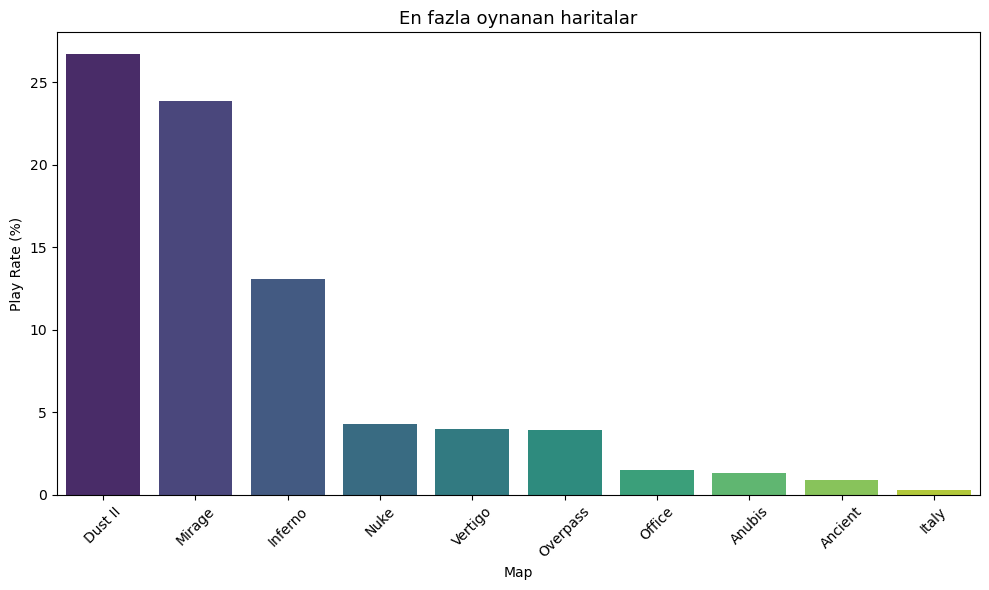

In [114]:
plt.figure(figsize=(10,6))
bar_plot = sns.barplot(x='Map',y='Play Rate',data=df_map_sort,palette='viridis')

plt.title('En fazla oynanan haritalar',fontsize=13)
plt.xlabel('Map',fontsize=10)
plt.ylabel('Play Rate (%)',fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

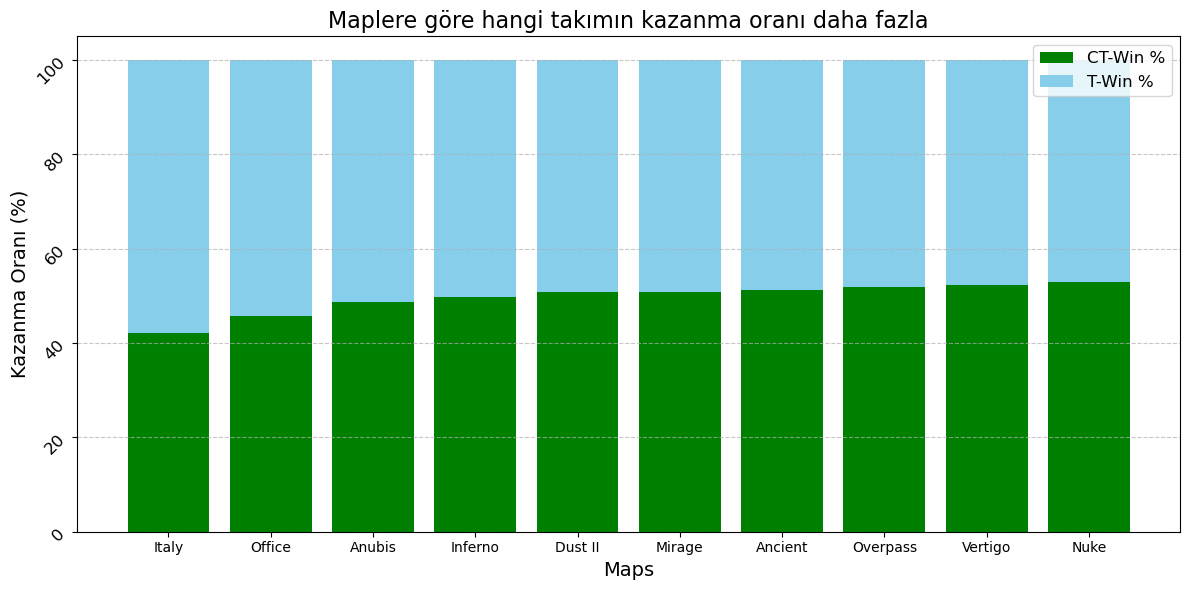

In [118]:
# Maplere göre hangi takımın kazanma oranı daha fazla...
df_win_percentages = df_maps.sort_values(by='T-Win %',ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_win_percentages['Map'],df_win_percentages['CT-Win %'],label = 'CT-Win %',color='green')
plt.bar(df_win_percentages['Map'],df_win_percentages['T-Win %'],bottom = df_win_percentages['CT-Win %'],label = 'T-Win %',color='skyblue')

plt.xlabel('Maps',fontsize=14)
plt.ylabel('Kazanma Oranı (%)',fontsize=14)
plt.title('Maplere göre hangi takımın kazanma oranı daha fazla',fontsize=16)
plt.legend(fontsize=12)
plt.yticks(rotation=45,ha='right',fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()